# Проект: Анализ поведения пользователей для повышения удержания клиентов



Автор проекта:  Чанышев Исмагил  
Дата: 04.03.2026  
ссылка на GitHub: https://github.com/Ismagil1234/Project_Module_2.git  


# Оглавление

[**1. Загрузка данных**](#1.-Загрузка-данных)  
[**2. Предобработка данных**](#2.-Предобработка-данных)  
[**3. Создание профиля пользователя**](#3.-Создание-профиля-пользователя)  
[**4. Исследовательский анализ данных**](#4.-Исследовательский-анализ-данных) 
- [**4.1. Исследование признаков первого заказа и их связи с возвращением на платформу**](#4.1.-Исследование-признаков-первого-заказа-и-их-связи-с-возвращением-на-платформу)  
- [**4.2. Исследование поведения пользователей через показатели выручки и состава заказа**](#4.2.-Исследование-поведения-пользователей-через-показатели-выручки-и-состава-заказа)  
- [**4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки**](#4.3.-Исследование-временных-характеристик-первого-заказа-и-их-влияния-на-повторные-покупки)
- [**4.4. Корреляционный анализ количества покупок и признаков пользователя**](#4.4.-Корреляционный-анализ-количества-покупок-и-признаков-пользователя)  

[**5. Общие выводы и рекомендации**](#5.-Общие-выводы-и-рекомендации)

## Введение

Команда маркетинга стремится лучше понимать поведение пользователей платформы с целью повышения уровня удержания клиентов. Для этого проводится исследовательский анализ данных, который позволит выявить закономерности в поведении пользователей и определить, какие факторы влияют на вероятность возврата клиентов и совершения повторных заказов.

### Цели проекта

1. Выявить пользователей с высокой вероятностью возврата на платформу
2. Определить признаки первого заказа, влияющие на повторные покупки
3. Проанализировать связь между метриками заказа (выручка, количество билетов) и удержанием клиентов
4. Сформулировать рекомендации для оптимизации маркетинговых бюджетов

### Задачи проекта

- Загрузка и предобработка данных из базы данных SQL
- Создание профиля пользователя с агрегированными признаками
- Исследовательский анализ данных (EDA)
- Корреляционный анализ признаков
- Формулировка выводов и рекомендаций



Выгрузка из базы данных SQL позволила собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ ( `mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk` );
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk` );
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.



# 1. Загрузка данных

**Цель шага:** Получить исходные данные для анализа из базы данных и провести первичную оценку их качества.

Выгружаем данные о заказах пользователей, включая информацию об устройствах, выручке, мероприятиях и временных интервалах между покупками. Фильтруем данные, исключая фильмы и оставляя только заказы с мобильных и десктопных устройств.

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
from dotenv import load_dotenv
import os

Задача 1.1: Напишем SQL-запрос, выгружающий в датафрейм pandas необходимые данные.

In [2]:
load_dotenv()


db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME'),
}



In [3]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [4]:
engine = create_engine(connection_string)

In [5]:
query = '''
SELECT user_id,
    device_type_canonical,
    order_id,
    created_dt_msk::DATE AS order_dt, 
    created_ts_msk AS order_ts,
    currency_code,
    revenue,
    tickets_count,
    created_dt_msk - LAG(created_dt_msk) OVER (PARTITION BY user_id ORDER BY created_dt_msk) AS days_since_prev,
    event_id,
    event_name_code AS event_name,
    service_name,
    event_type_main,
    region_name,
    city_name
FROM afisha.purchases AS p
JOIN afisha.events AS e USING(event_id)
JOIN afisha.city AS c USING(city_id)
JOIN afisha.regions AS r USING(region_id)
WHERE (device_type_canonical = 'desktop' OR device_type_canonical = 'mobile' ) AND NOT event_type_main ='фильм'
ORDER BY user_id
''' 

In [6]:
df = pd.read_sql_query(query, con=engine)

In [7]:
df.head()


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaT,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaT,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75 days,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaT,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83 days,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype          
---  ------                 --------------   -----          
 0   user_id                290611 non-null  object         
 1   device_type_canonical  290611 non-null  object         
 2   order_id               290611 non-null  int64          
 3   order_dt               290611 non-null  object         
 4   order_ts               290611 non-null  datetime64[ns] 
 5   currency_code          290611 non-null  object         
 6   revenue                290611 non-null  float64        
 7   tickets_count          290611 non-null  int64          
 8   days_since_prev        268678 non-null  timedelta64[ns]
 9   event_id               290611 non-null  int64          
 10  event_name             290611 non-null  object         
 11  service_name           290611 non-null  object         
 12  event_type_main        290611 

### Промежуточный вывод по Шагу 1

- Получено 290 611 записей о заказах
- Данные содержат 15 столбцов с информацией о пользователях, заказах и мероприятиях
- Столбец `days_since_prev` содержит пропуски для пользователей с одним заказом (ожидаемое поведение)
- Требуется предобработка: конвертация валют, исправление типов данных, фильтрация выбросов
- order_dt можно перевести в формат даты
- tickets_count можно понизить разрядность

# 2. Предобработка данных

**Цель шага:** Подготовить данные к анализу, обеспечив их корректность и сопоставимость.

загрузка информации с курсом казахского тенге. Значения в рублях представлено для 100 тенге.

In [9]:
df_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [10]:
df_tenge

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
...,...,...,...,...
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt


Видно, что строк 356. проверим только, чтобы не повторялись значения дней

In [11]:
df_tenge['data'].duplicated().sum()

0

In [12]:
df_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


добавим в исходную таблицу с данными столбцы nominal и curs из таблицы с курсом валют. объединяем по столбцам order_dt и data, предварительно преобразовав тип данных в datetime, чтобы исключить ошибки

In [13]:
df['order_dt'] = pd.to_datetime(df['order_dt'], format='%Y-%m-%d')
df_tenge['data'] = pd.to_datetime(df_tenge['data'], format='%Y-%m-%d')

In [14]:
df = df.merge(df_tenge, how = 'left', left_on = 'order_dt', right_on ='data')

In [15]:
df.head(2)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,data,nominal,curs,cdx
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaT,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск,2024-08-20,100,18.6972,kzt
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaT,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск,2024-07-23,100,18.3419,kzt


добавим столбец `revenue_rub` и удалим лишние столбцы

In [16]:
# создаем новый столбец с выручкой пересчитанной в рубли
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)

In [17]:
del df['data']
del df['nominal']
del df['curs']
del df['cdx']

In [18]:
df.head(2)


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaT,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaT,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск,289.45


Все прошло хорошо. Выручка из тенге конвертирована в рубли

**Задача 2.2.**

- Проверим данные на пропущенные значения.
- Преобразуем типы данных в некоторых столбцах, если это необходимо. 
- Изучим значения в ключевых столбцах. 
    - Проверим, какие категории указаны в столбцах с номинальными данными. 
    - Проверим распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха. Важные показатели в рамках поставленной задачи — это выручка с заказа ( `revenue_rub` ) и количество билетов в заказе ( `tickets_count` ), поэтому в первую очередь проверим данные в этих столбцах. Если обнаружим выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.



In [19]:
tmp = df # сохраним копию датасета для подсчета того, что отфильтруем
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype          
---  ------                 --------------   -----          
 0   user_id                290611 non-null  object         
 1   device_type_canonical  290611 non-null  object         
 2   order_id               290611 non-null  int64          
 3   order_dt               290611 non-null  datetime64[ns] 
 4   order_ts               290611 non-null  datetime64[ns] 
 5   currency_code          290611 non-null  object         
 6   revenue                290611 non-null  float64        
 7   tickets_count          290611 non-null  int64          
 8   days_since_prev        268678 non-null  timedelta64[ns]
 9   event_id               290611 non-null  int64          
 10  event_name             290611 non-null  object         
 11  service_name           290611 non-null  object         
 12  event_type_main        290611 

In [20]:
# понизим размерность столбца tickets_count
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast = 'integer')

изучим столбцы с категориальными данными на предмет неявных дубликатов и значений, обозначающих пропуски

In [21]:
# изучим столбец device_type_canonical
df['device_type_canonical'].unique()

array(['mobile', 'desktop'], dtype=object)

In [22]:
# изучим столбец currency_code
df['currency_code'].unique()

array(['rub', 'kzt'], dtype=object)

In [23]:
# изучим столбец service_name
df['service_name'].unique()

array(['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!',
       'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная',
       'Быстробилет', 'Дом культуры', 'Весь в билетах', 'Билеты в руки',
       'Тебе билет!', 'Show_ticket', 'Городской дом культуры', 'Яблоко',
       'Билет по телефону', 'Выступления.ру', 'Росбилет',
       'Шоу начинается!', 'Мир касс', 'Восьмёрка', 'Телебилет',
       'Crazy ticket!', 'Реестр', 'Быстрый кассир', 'КарандашРУ',
       'Радио ticket', 'Дырокол', 'Вперёд!', 'Кино билет', 'Цвет и билет',
       'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете'],
      dtype=object)

In [24]:
# изучим столбец event_type_main
df['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

In [25]:
# изучим столбец region_name
df['region_name'].sort_values().unique()

array(['Белоярская область', 'Берестовский округ', 'Берёзовская область',
       'Боровлянский край', 'Верховинская область', 'Верхозёрский край',
       'Верхоречная область', 'Ветренский регион', 'Вишнёвский край',
       'Глиногорская область', 'Голубевский округ',
       'Горицветская область', 'Горноземский регион',
       'Горностепной регион', 'Дальнеземская область',
       'Дальнезорский край', 'Дубравная область', 'Залесский край',
       'Заречная область', 'Зеленоградский округ', 'Златопольский округ',
       'Золотоключевской край', 'Зоринский регион', 'Каменевский регион',
       'Каменичская область', 'Каменноозёрный край', 'Каменноярский край',
       'Каменополянский округ', 'Ключеводский округ',
       'Кристаловская область', 'Кристальная область',
       'Крутоводская область', 'Крутоводский регион', 'Лесноярский край',
       'Лесодальний край', 'Лесополянская область', 'Лесостепной край',
       'Лесоярская область', 'Луговая область', 'Лугоградская область',
    

In [26]:
# изучим столбец city_name
df['city_name'].sort_values().unique()

array(['Айкольск', 'Айсуак', 'Акбастау', 'Акбасты', 'Акжолтау',
       'Алтынкала', 'Алтынсай', 'Байкуль', 'Байсары', 'Байтерековск',
       'Беловодск', 'Белоярск', 'Бережанка', 'Бережанск', 'Березиногорск',
       'Березиноск', 'Березовцево', 'Берестовец', 'Берестяград',
       'Берёзиново', 'Берёзовка', 'Берёзогорск', 'Берёзодальн',
       'Берёзополье', 'Берёзореч', 'Берёзоречье', 'Бозарык', 'Боровлянск',
       'Буркиттау', 'Бурьяново', 'Верховино', 'Верховка', 'Верхозолотск',
       'Верхозорье', 'Верхоозёров', 'Ветеринск', 'Вишнёво',
       'Вишнёвогорск', 'Вишнёводск', 'Водниково', 'Глиногорск',
       'Глиногорь', 'Глиноград', 'Глинозолото', 'Глинозорь', 'Глинолес',
       'Глинополин', 'Глинополье', 'Глинополянск', 'Глинореч', 'Глинянск',
       'Голубевск', 'Голубино', 'Гореловск', 'Горицветск', 'Горноград',
       'Горнодолинск', 'Горнолесье', 'Горнолуг', 'Горнополец',
       'Горнополье', 'Горнополянск', 'Горнополяровск', 'Горнополёк',
       'Горноставинск', 'Горяново', '

In [27]:
   # Анализ категориальных значений
for column in ['device_type_canonical', 'currency_code', 'service_name', 'event_type_main', 'region_name', 'city_name']:
    print(f"\nColumn: {column}")
    print("Unique values:", df[column].unique())
    print("Missing values count:", df[column].isna().sum())
    print("Value counts:")
    print(df[column].value_counts(dropna=False), "\n")


Column: device_type_canonical
Unique values: ['mobile' 'desktop']
Missing values count: 0
Value counts:
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64 


Column: currency_code
Unique values: ['rub' 'kzt']
Missing values count: 0
Value counts:
rub    285542
kzt      5069
Name: currency_code, dtype: int64 


Column: service_name
Unique values: ['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!' 'Мир касс' 'Восьмёрка'
 'Телебилет' 'Crazy ticket!' 'Реестр' 'Быстрый кассир' 'КарандашРУ'
 'Радио ticket' 'Дырокол' 'Вперёд!' 'Кино билет' 'Цвет и билет' 'Зе Бест!'
 'Тех билет' 'Лимоны' 'Билеты в интернете']
Missing values count: 0
Value counts:
Билеты без проблем        63519
Лови билет!               41124
Бил

Глиногорск      89446
Озёрск          43910
Радужсвет       13711
Радужнополье     8741
Верховино        6579
                ...  
Крутовичи           1
Кристолесье         1
Глинополянск        1
Голубевск           1
Ягодинска           1
Name: city_name, Length: 352, dtype: int64 



Категориальные признаки в порядке и не требуют нормализации.  
Видны категории, в которых мало значений:
- оператор: "Лимоны" -8 шт, "Зе бест!" - 5 шт, "Билеты в интернете" - 3шт  
- регионы: Верхозёрский край - 11 шт, Сосноводолинская область - 10 шт, Теплоозёрский округ - 7 шт
- города: Крутовичи, Синеполинск, Кристолесье и другие по 1 значению

т.е. при подсчёте статистик, нужно будет учесть, что могут попадаться категории со статистически незначащими выборками

Проверим распределение численных данных и наличие в них выбросов

столбец revenue_rub

In [28]:
df['revenue_rub'].describe()

count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

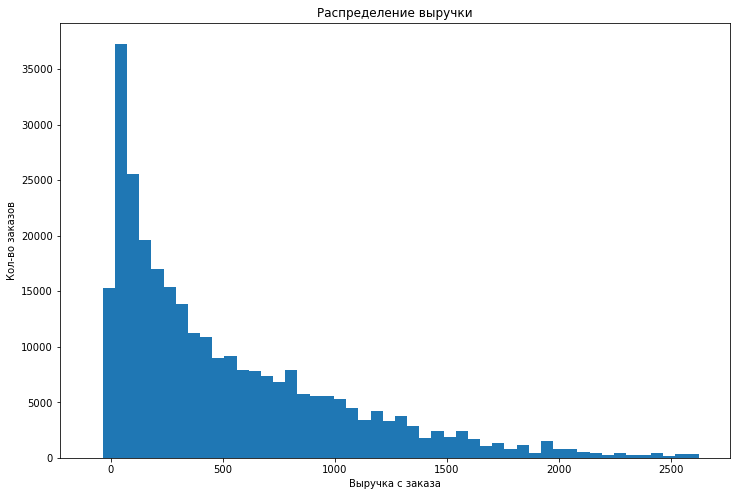

In [29]:
# нарисуем диаграмму , отфильтровав 99-процентиль, т.к. большие выбросы
plt.figure(figsize = (12,8))
plt.hist(df[(df['revenue_rub'] < df['revenue_rub'].quantile(0.99))]['revenue_rub'], bins = 50)
plt.title('Распределение выручки')
plt.xlabel('Выручка с заказа')
plt.ylabel('Кол-во заказов')
plt.show()


Text(0.5, 0, 'Выручка, руб.')

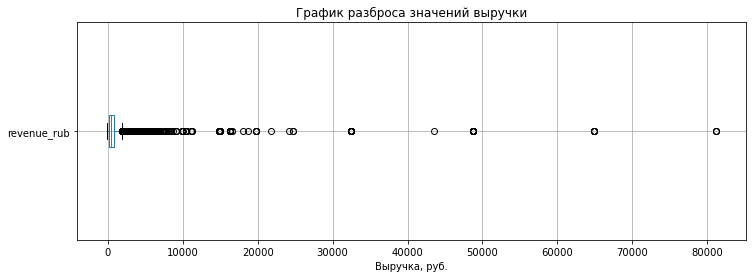

In [30]:
df.boxplot(column = 'revenue_rub', vert=False, figsize = (12,4))
plt.title('График разброса значений выручки')
plt.xlabel('Выручка, руб.')

отфильтруем выбросы

Text(0.5, 0, 'Выручка, руб.')

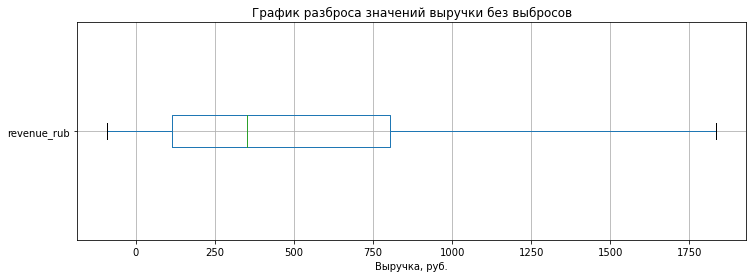

In [31]:
df.boxplot(column = 'revenue_rub', vert=False, figsize = (12,4), showfliers= False)
plt.title('График разброса значений выручки без выбросов')
plt.xlabel('Выручка, руб.')

сделаем то же с tickets_count

In [32]:
df['tickets_count'].describe()

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

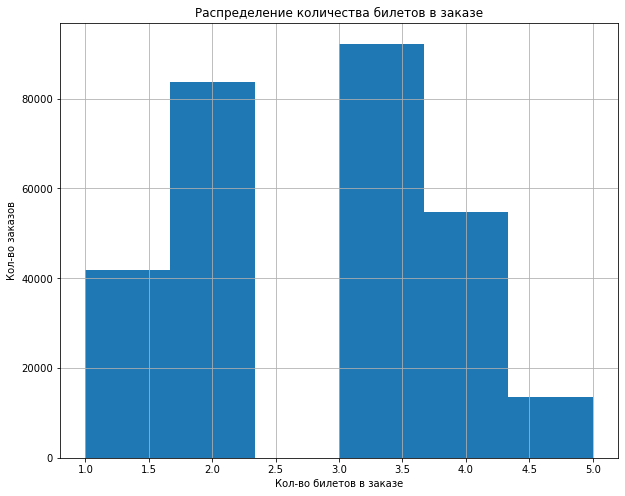

In [33]:
# нарисуем диаграмму , отфильтровав 99-процентиль, т.к. большие выбросы
df[(df['tickets_count'] < df['tickets_count'].quantile(0.99))].hist(column = 'tickets_count', bins = 6, figsize = (10,8))
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Кол-во билетов в заказе')
plt.ylabel('Кол-во заказов')
plt.show()


Text(0.5, 0, 'Кол-во билетов')

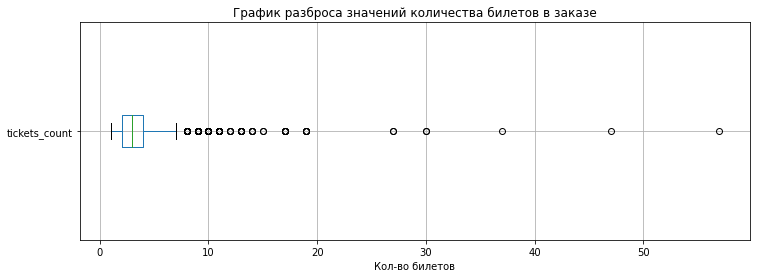

In [34]:
df.boxplot(column = 'tickets_count', vert=False, figsize = (12,4))
plt.title('График разброса значений количества билетов в заказе')
plt.xlabel('Кол-во билетов')

Text(0.5, 0, 'Кол-во билетов')

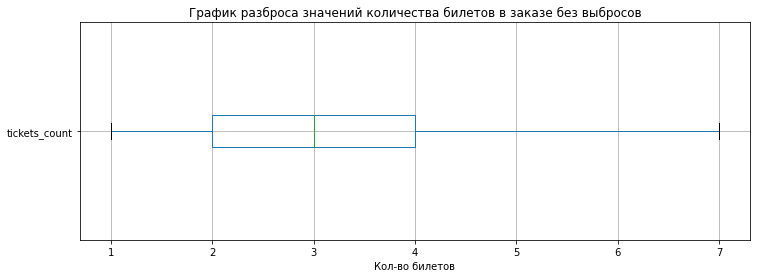

In [35]:
df.boxplot(column = 'tickets_count', vert=False, figsize = (12,4), showfliers= False)
plt.title('График разброса значений количества билетов в заказе без выбросов')
plt.xlabel('Кол-во билетов')

In [36]:
# Обоснуем удаление выбросов
df[['revenue_rub', 'tickets_count']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,revenue_rub,tickets_count
count,290611.000000,290611.000000
mean,555.571987,2.754311
std,875.498172,1.170620
min,-90.760000,1.000000
25%,113.970000,2.000000
50%,351.140000,3.000000
75%,802.050000,4.000000
90%,1294.770000,4.000000
95%,1630.650000,5.000000
99%,2628.421739,6.000000


По графикам видно, что в этих двух столбцах (выручка и кол-во билетов в заказе) имеются выбросы. поэтому нужно отфильтровать данные

Также по таблице со статистиками видно, что в выручке медиана (351 р.) сильно меньше, чем среднее (875 р.) из-за того, что сильно большие выбросы оттягивают среднее значение в большую сторону. При этом стандартное отклонение сильно больше среднего значения. И при этом  99-процентиль имеет значение 2628 р., а максимальное 81174 р.  

По столбцу количества билетов видно, что 99-процентиль 6, а максимальное значение 57. на самом деле можно было бы и не удалять выбросы, но т.к. их немного всё-таки удалим, чтобы иметь более репрезентативную выборку

Также в столбце revenue_rub присутствуют отрицательные значения. Они связаны возможно со скидками или возвратами.
Оценим, сколько их, чтобы удалить


In [37]:
negative_revenue = df[df['revenue_rub']<0].shape[0]
print(f'Отрицательных значениий: {negative_revenue}')

Отрицательных значениий: 381


Их совсем немного, можно легко удалить

Отфильтруем и оценим, в каком объёме были отфильрованы данные. 

In [38]:
tmp = df
# для столбца revenue_rub были отфильтрованы данные
rows_filtered = df[(df['revenue_rub'] < df['revenue_rub'].quantile(0.99)) & (df['revenue_rub'] > 0)].shape[0]
total = df.shape[0]
filtered_perc = round(rows_filtered / total * 100, 2)
print(f'Для столбца "revenue_rub" было отфильтровано {rows_filtered} строк из {total}, {filtered_perc}%.')


df = df[(df['revenue_rub'] < df['revenue_rub'].quantile(0.99)) & (df['revenue_rub'] > 0)]

# для столбца tickets_count были отфильтрованы данные
rows_filtered = df[(df['tickets_count'] < df['tickets_count'].quantile(0.99))].shape[0]
total = df.shape[0]
filtered_perc = round(rows_filtered / total * 100, 2)
print(f'Для столбца "tickets_count" было отфильтровано {rows_filtered} строк из {total}, {filtered_perc}%.')

# фильтруем
df = df[(df['tickets_count'] < df['tickets_count'].quantile(0.99))]


print()
print(f'Всего отфильтровано {df.shape[0]} строк из {tmp.shape[0]}, что составляет {round(df.shape[0] / tmp.shape[0] *100, 2)}%')

Для столбца "revenue_rub" было отфильтровано 281697 строк из 290611, 96.93%.
Для столбца "tickets_count" было отфильтровано 277603 строк из 281697, 98.55%.

Всего отфильтровано 277603 строк из 290611, что составляет 95.52%


**Проверка на дубликаты**


In [39]:
print(f"Дубликатов в столбце order_id: {df.duplicated(subset='order_id').sum()}")
print(f"Полных дубликатов: {df.duplicated().sum()}")


Дубликатов в столбце order_id: 0
Полных дубликатов: 0


### Что было сделано:

1. **Конвертация валют:** Добавлен курс казахского тенге, все значения приведены к рублям через столбец `revenue_rub`
2. **Преобразование типов данных:**
    - `order_dt` преобразован в datetime
    - `tickets_count` понижена разрядность
3. **Проверка на пропуски:** Пропуски обнаружены только в столбце `days_since_prev` (21 933 значений)
4. **Фильтрация выбросов:**
    - По `revenue_rub` удалено 3% данных (выше 99-й перцентиля и отрицательные значения)
    - По `tickets_count` удалено 1,5% данных (выше 99-й перцентиля)
5. **Проверка дубликатов:** Дубликаты не обнаружены

### Промежуточный вывод по Шагу 2

- Данные приведены к единой валюте (рубли)
- Выявлены и отфильтрованы статистические выбросы по выручке и количеству билетов
- Данные проверены на наличие явных дубликатов
- Категориальные данные проверены на наличие неявных дубликатов
- Dataset готов для агрегации и создания профилей пользователей

---

# 3. Создание профиля пользователя

**Цель шага:** Сформировать агрегированные признаки для каждого пользователя, описывающие его поведение и историю заказов.


**Задача 3.1.** Построим профиль пользователя — для каждого пользователя найдём:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используем поле `event_type_main` );
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавим два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.


In [40]:
df_users = df.groupby(by='user_id').agg(
    first_order_dt = ('order_dt', 'min'),
    last_order_dt = ('order_dt', 'max'),
    first_order_device = ('device_type_canonical', 'first'),
    first_order_region = ('region_name', 'first'),
    first_order_service = ('service_name', 'first'),
    first_order_event = ('event_type_main', 'first'),
    total_orders = ('order_id', 'count'),
    revenue_mean = ('revenue_rub', 'mean'),
    total_tickets = ('tickets_count', 'sum')
).reset_index()
df_users['avg_tickets_in_order'] = df_users['total_tickets'] / df_users['total_orders']
del df_users['total_tickets']
df_users['avg_days_between_orders'] = (df_users['last_order_dt'] - df_users['first_order_dt']) / (df_users['total_orders'] - 1)

# напишем функцию, определяющую бинарные признаки
def is_two(row):
    return row['total_orders'] >= 2

def is_five(row):
    return row['total_orders'] >= 5
        
df_users['is_two'] = df_users.apply(is_two, axis = 1)
df_users['is_five'] = df_users.apply(is_five, axis = 1)
df_users

,user_id,first_order_dt,last_order_dt,first_order_device,first_order_region,first_order_service,first_order_event,total_orders,revenue_mean,avg_tickets_in_order,avg_days_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaT,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75 days 00:00:00,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51 days 00:00:00,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaT,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16 days 00:00:00,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21546,fff13b79bd47d7c,2024-07-16,2024-10-31,mobile,Каменевский регион,Мой билет,другое,9,688.043333,2.555556,13 days 09:00:00,True,True
21547,fff32fc9ad0f9f6,2024-08-15,2024-10-28,desktop,Каменевский регион,Билеты без проблем,стендап,2,850.995000,2.500000,74 days 00:00:00,True,False
21548,fffcd3dde79eb2c,2024-06-20,2024-10-30,desktop,Каменевский регион,Билеты без проблем,концерты,31,504.308710,2.580645,4 days 09:36:00,True,True
21549,fffeeb3c120cf0b,2024-09-24,2024-09-24,desktop,Широковская область,Билеты без проблем,стендап,1,661.530000,2.000000,NaT,False,False


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными мы работаем: насколько они репрезентативны и нет ли в них аномалий.


Используя данные о профилях пользователей, рассчитаем:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

In [41]:
# считаем общее число ползователей в выборке
users_count = df_users.shape[0]
# считаем среднюю выручку с одного заказа
avg_revenue = round(df_users['revenue_mean'].mean(), 2)
#долю пользователей, совершивших 2 и более заказа
is_two_share = round(df_users['is_two'].mean(), 2)
#долю пользователей, совершивших 5 и более заказов
is_five_share = round(df_users['is_five'].mean(), 2)

print(f'общее число ползователей в выборке: {users_count}')
print(f'средняя выручка с одного заказа: {avg_revenue}')
print(f'доля пользователей, совершивших 2 и более заказа: {is_two_share}')
print(f'доля пользователей, совершивших 5 и более заказов: {is_five_share}')

общее число ползователей в выборке: 21551
средняя выручка с одного заказа: 546.29
доля пользователей, совершивших 2 и более заказа: 0.62
доля пользователей, совершивших 5 и более заказов: 0.29


Также изучим статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

In [42]:
df_users[['total_orders', 'avg_tickets_in_order', 'avg_days_between_orders']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,total_orders,avg_tickets_in_order,avg_days_between_orders
count,21551.000000,21551.000000,13271
mean,12.881212,2.698722,15 days 22:28:41.943763613
std,118.143237,0.853409,22 days 07:20:57.299989001
min,1.000000,1.000000,0 days 00:00:00
25%,1.000000,2.000000,1 days 00:00:00
50%,2.000000,2.700000,8 days 04:00:00
75%,5.000000,3.000000,20 days 14:24:00
90%,15.000000,4.000000,41 days 12:00:00
95%,31.000000,4.000000,61 days 00:00:00
99%,149.500000,5.000000,112 days 00:00:00


### Статистика по выборке (после фильтрации):

- **Общее число пользователей:** 21 551
- **Средняя выручка с заказа:** 546 руб.
- **Доля пользователей с 2+ заказами:** 62%
- **Доля пользователей с 5+ заказами:** 29%

Text(0.5, 0, 'Кол-во заказов')

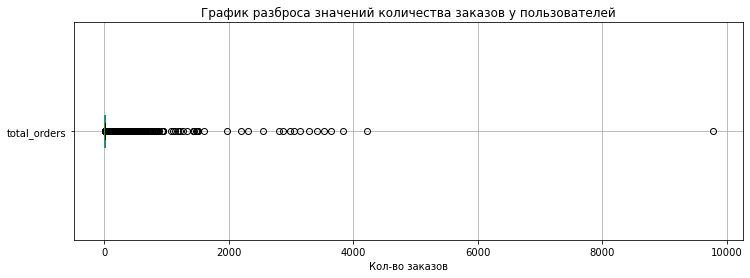

In [43]:
df_users.boxplot(column = 'total_orders', vert=False, figsize = (12,4))
plt.title('График разброса значений количества заказов у пользователей')
plt.xlabel('Кол-во заказов')

Text(0.5, 0, 'Кол-во заказов')

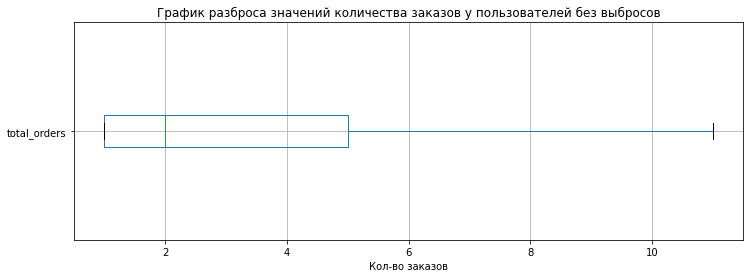

In [44]:
df_users.boxplot(column = 'total_orders', vert=False, figsize = (12,4), showfliers = False)
plt.title('График разброса значений количества заказов у пользователей без выбросов')
plt.xlabel('Кол-во заказов')

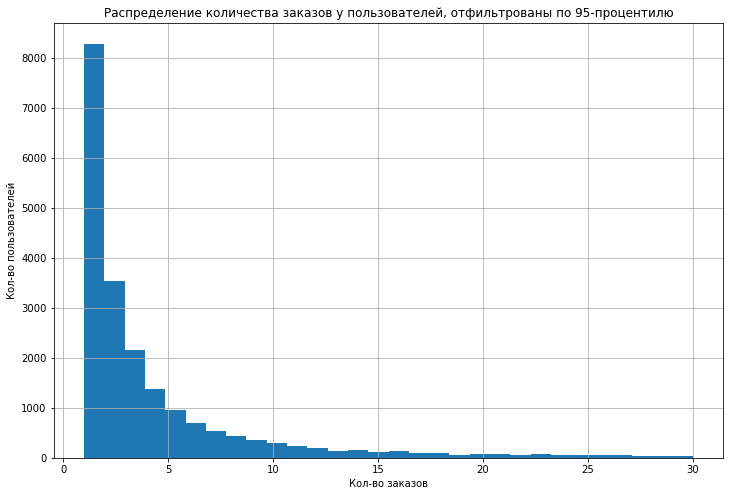

In [45]:
df_users[(df_users['total_orders'] < df_users['total_orders'].quantile(0.95))].hist(column = 'total_orders', bins = 30, figsize = (12,8))
plt.title('Распределение количества заказов у пользователей, отфильтрованы по 95-процентилю')
plt.xlabel('Кол-во заказов')
plt.ylabel('Кол-во пользователей')
plt.show()


отфильруем по 95-процентилю

In [46]:
users_tmp = df_users # сохраним исходный датасет для сравнения
df_users = df_users[(df_users['total_orders'] < df_users['total_orders'].quantile(0.95))]
df_users[['total_orders', 'avg_tickets_in_order', 'avg_days_between_orders']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,total_orders,avg_tickets_in_order,avg_days_between_orders
count,20460.000000,20460.000000,12180
mean,3.975904,2.699326,17 days 03:53:20.503218109
std,4.958379,0.873922,22 days 21:14:07.039608797
min,1.000000,1.000000,0 days 00:00:00
25%,1.000000,2.000000,1 days 00:00:00
50%,2.000000,2.714286,9 days 14:35:04.615384615
75%,4.000000,3.000000,22 days 12:00:00
90%,10.000000,4.000000,44 days 00:00:00
95%,15.000000,4.000000,64 days 00:00:00
99%,25.000000,5.000000,115 days 00:00:00


In [47]:
print('Средняя выручка после удаления')
round(df_users['revenue_mean'].mean(), 2)


Средняя выручка после удаления


548.39

**Как изменилась средняя выручка:**  

До удаления выбросов: 546р.
После удаления выбросов: 548 р.


In [48]:
filtered_rows = df_users.shape[0]

print(f'Отфильтровано {df_users.shape[0]} строк из {users_tmp.shape[0]}, {round(df_users.shape[0] / users_tmp.shape[0] *100, 2)}%')

Отфильтровано 20460 строк из 21551, 94.94%


### Промежуточный вывод по Шагу 3

- **Объём данных достаточен** для выявления закономерностей и сегментации пользователей.
- **Аномалии в `total_orders`** обусловлены наличием сверхактивных пользователей (возможно, корпоративные аккаунты или боты). Их фильтрация по 95-му перцентилю повышает надёжность анализа.
- **Данные по билетам** не требуют дополнительной обработки — распределение близко к нормальному с умеренным разбросом.
- После предобработки выборка из 20 460 пользователей готова к исследовательскому анализу.

---


# 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используем профили пользователей.

## 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

**Цель шага:**  

Провести исследовательский анализ данных, чтобы понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно. Это позволит:  
- Быстро выявлять перспективных клиентов и предлагать им персонализированные условия.
- Точно настраивать рекламу на аудитории с высокой вероятностью возврата.
- Оптимизировать маркетинговые бюджеты.
- Повысить общий уровень удержания клиентов.  

Исследуем признаки, описывающие первый заказ пользователя, и выясним, влияют ли они на вероятность возвращения пользователя.

**Задача 4.1.1.** Изучим распределение пользователей по признакам.

- Сгруппируем пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитаем общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. 
- Исследуем, равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей.

In [49]:
df_users.head()


,user_id,first_order_dt,last_order_dt,first_order_device,first_order_region,first_order_service,first_order_event,total_orders,revenue_mean,avg_tickets_in_order,avg_days_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaT,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75 days,True,False
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51 days,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaT,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16 days,True,False


In [50]:
# напишем функцию, считающую количество и долю клиентов в категории
def count_and_pct(df, column):
    counts = df[column].value_counts()
    pct = df[column].value_counts(normalize=True).round(3) * 100
    result = pd.DataFrame({
        'количество': counts,
        'доля_%': pct
    })
    return result

In [51]:
# применим функцию к столбцу first_order_event
event_stats = count_and_pct(df_users, 'first_order_event')
event_stats

,количество,доля_%
концерты,9205,45.0
другое,4911,24.0
театр,4048,19.8
стендап,1061,5.2
спорт,737,3.6
выставки,403,2.0
ёлки,95,0.5


In [52]:
# для сравнения по всем заказам, а не только по первому заказу
count_and_pct(df, 'event_type_main').head()

,количество,доля_%
концерты,111495,40.2
театр,65583,23.6
другое,59859,21.6
спорт,20966,7.6
стендап,13017,4.7


In [53]:
# применим функцию к столбцу first_order_device
event_stats = count_and_pct(df_users, 'first_order_device')
event_stats

,количество,доля_%
mobile,16971,82.9
desktop,3489,17.1


In [54]:
# для сравнения по всем заказам, а не только по первому заказу
count_and_pct(df, 'device_type_canonical').head()

,количество,доля_%
mobile,222692,80.2
desktop,54911,19.8


In [55]:
# применим функцию к столбцу first_order_region
event_stats = count_and_pct(df_users, 'first_order_region')
event_stats

,количество,доля_%
Каменевский регион,6653,32.5
Североярская область,3562,17.4
Широковская область,1181,5.8
Озернинский край,659,3.2
Малиновоярский округ,515,2.5
...,...,...
Тихогорская область,2,0.0
Сосноводолинская область,1,0.0
Светолесский край,1,0.0
Яснопольский округ,1,0.0


In [56]:
# для сравнения по всем заказам, а не только по первому заказу
count_and_pct(df, 'region_name').head()

,количество,доля_%
Каменевский регион,84265,30.4
Североярская область,42860,15.4
Широковская область,15785,5.7
Медовская область,13282,4.8
Озернинский край,10301,3.7


In [57]:
# применим функцию к столбцу first_order_service
event_stats = count_and_pct(df_users, 'first_order_service')
event_stats

,количество,доля_%
Билеты без проблем,4699,23.0
Мой билет,2859,14.0
Лови билет!,2683,13.1
Билеты в руки,2402,11.7
Облачко,2127,10.4
Весь в билетах,1219,6.0
Лучшие билеты,1125,5.5
Прачечная,554,2.7
Край билетов,441,2.2
Дом культуры,337,1.6


In [58]:
# для сравнения по всем заказам, а не только по первому заказу
count_and_pct(df, 'service_name').head()

,количество,доля_%
Билеты без проблем,56996,20.5
Лови билет!,39945,14.4
Билеты в руки,39129,14.1
Мой билет,33527,12.1
Облачко,26204,9.4


#### Вывод по задаче 4.1.1

Анализ распределения пользователей по сегментам в первых заказах показывает выраженную неоднородность, которая, однако, практически полностью повторяет структуру всех заказов на платформе. Это важное наблюдение, позволяющее сделать обоснованные выводы о природе привлечения пользователей.

**Кто доминирует в первых заказах?**  
Наибольшую долю в структуре первых заказов занимают:

- **Концерты** (45%) — практически каждый второй новый пользователь начинает знакомство с платформой именно с покупки билетов на концерты. Это ожидаемо, учитывая массовость и маркетинговую привлекательность данного типа мероприятий.
    
- **Мобильные устройства** (82,9%) — подавляющее большинство пользователей оформляют первый заказ со смартфонов. Это отражает общий тренд на мобилизацию трафика и удобство использования приложения/мобильной версии сайта.
    
- **Каменевский регион** (32,5%) — каждый третий новый пользователь гео-привязан к этому региону, что указывает на его высокую деловую активность и развитую событийную инфраструктуру.
    
- **Оператор «Билеты без проблем»** (23%) — почти четверть всех первых продаж проходит через этого оператора, что свидетельствует о его популярности и доверии со стороны пользователей.
    

**Что при этом важно понимать?**  
Сравнение с распределением по **всем заказам** показывает, что эти же сегменты лидируют и в общей структуре продаж:

- Концерты: 40,2% (разница всего +4,8 п.п.)
    
- Mobile: 80,2% (разница +2,7 п.п.)
    
- Каменевский регион: 30,4% (разница +2,5 п.п.)
    
- Оператор «Билеты без проблем»: 20,5% (разница +2,5 п.п.)
    

Незначительная разница (в пределах 1–5 процентных пунктов) говорит о том, что высокая доля этих сегментов в **первых** заказах — это не признак их уникальной эффективности как «точек входа», а лишь отражение общей популярности этих каналов и категорий на платформе. Они доминируют **везде**, потому что являются основой бизнеса.

**Что пользуется меньшим спросом?**  
На противоположном полюсе находятся сегменты с минимальной долей в первых заказах:

- Типы мероприятий: **Экскурсии (менее 1%)** и **Выставки (около 2%)** — возможно, это нишевые продукты, которые пользователи открывают для себя позже, либо они требуют дополнительного промотирования.
    
- Устройства: **Desktop (17,1%)** — значительно уступает мобильным платформам, что подтверждает глобальный сдвиг в сторону мобильного потребления.
    
- Операторы: **Реестр и Быстрый кассир (менее 0,5%)** — крайне низкая доля, возможно, из-за специфики их интеграции или менее удобного пользовательского опыта на этапе первого знакомства с сервисом.
    

**Практическое значение:**  
Интерпретировать сегменты-лидеры (концерты, mobile, Каменевский регион) как «успешные точки входа» было бы преждевременно. Их высокие абсолютные доли — это следствие их рыночной силы, а не уникальной способности привлекать именно новых клиентов. Чтобы выявить реальные драйверы роста и удержания, необходим анализ **конверсии в повторные покупки** внутри каждого сегмента. Именно он покажет, какие каналы не просто приносят много трафика, а привлекают лояльных пользователей. Этот анализ выполнен в задаче 4.1.2.

**Сравнение распределения: первый заказ vs все заказы**

| Признак         | Сегмент            | Доля в первых заказах | Доля во всех заказах | Разница   |
| --------------- | ------------------ | --------------------- | -------------------- | --------- |
| Тип мероприятия | Концерты           | 45.0%                 | 40.2%                | +4.8 п.п. |
| Устройство      | Mobile             | 82.9%                 | 80.2%                | +2.7 п.п. |
| Регион          | Каменевский регион | 32.5%                 | 30.4%                | +2.5 п.п. |
| Оператор        | Билеты без проблем | 23.0%                 | 20.5%                | +2.5 п.п. |



---


**Задача 4.1.2.** Проанализируем возвраты пользователей:

- Для каждого сегмента вычислим долю пользователей, совершивших два и более заказа.
- Визуализируем результат подходящим графиком. Если сегментов слишком много, то поместим на график только 10 сегментов с наибольшим количеством пользователей. 
- Ответим на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?



                   count      mean
first_order_event                 
выставки             403  0.630273
театр               4048  0.617836
концерты            9205  0.600000
стендап             1061  0.593779
другое              4911  0.575850
ёлки                  95  0.536842
спорт                737  0.533243


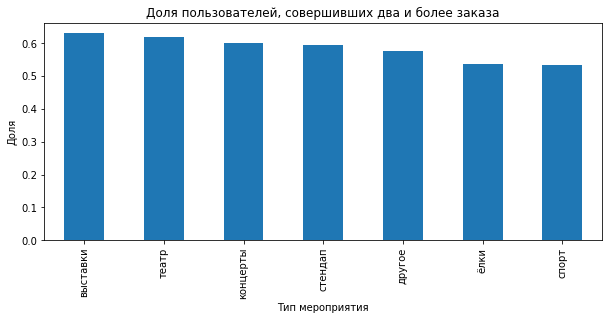

In [59]:
# считаем и визуализируем долю пользователей, совершивших два и более заказа в категории типа мероприятия
event_mean = df_users.groupby(by='first_order_event')['is_two'].agg(['count', 'mean']).sort_values(by='mean', ascending=False)
print(event_mean)
plt.figure(figsize=(10, 4))
event_mean['mean'].plot(kind='bar', legend=False, xlabel = 'Тип мероприятия', ylabel = 'Доля')
plt.title('Доля пользователей, совершивших два и более заказа')
plt.show()

                    count      mean
first_order_device                 
desktop              3489  0.620235
mobile              16971  0.590183


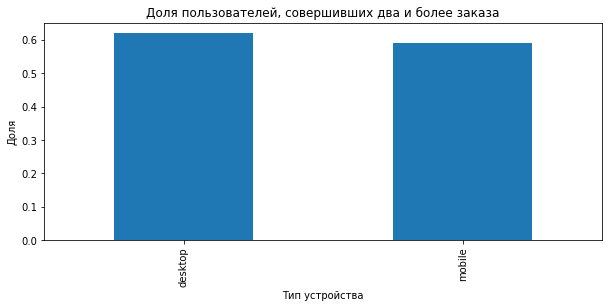

In [60]:
# считаем и визуализируем долю пользователей, совершивших два и более заказа в категории типа устройства
device_mean = df_users.groupby(by='first_order_device')['is_two'].agg(['count', 'mean']).sort_values(by='mean', ascending=False)
print(device_mean)
plt.figure(figsize=(10, 4))
device_mean['mean'].plot(kind='bar', legend=False, xlabel = 'Тип устройства', ylabel = 'Доля')
plt.title('Доля пользователей, совершивших два и более заказа')
plt.show()

                        count      mean
first_order_region                     
Верхозёрский край           1  1.000000
Озернопольская область     27  0.888889
Радужнопольский край       21  0.761905
Тихолесский край           10  0.700000
Горноземский регион        25  0.680000
Лесостепной край           55  0.672727
Лесноярский край            3  0.666667
Шанырский регион          425  0.665882
Ягодиновская область       62  0.661290
Лесоярская область         17  0.647059


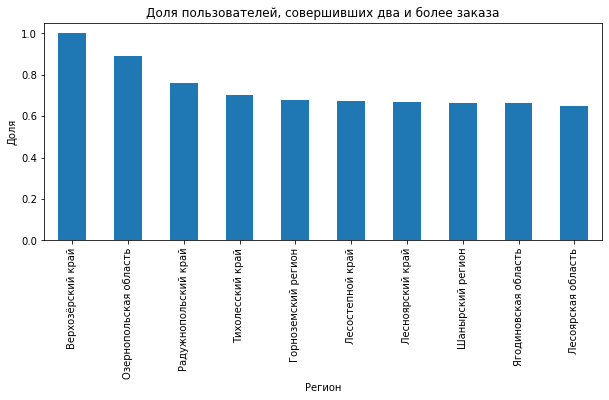

In [61]:
# считаем и визуализируем долю пользователей, совершивших два и более заказа в категории регион
region_mean = df_users.groupby(by='first_order_region')['is_two'].agg(['count', 'mean']).sort_values(by='mean', ascending=False).head(10)
print(region_mean)
plt.figure(figsize=(10, 4))
region_mean['mean'].plot(kind='bar', legend=False, xlabel = 'Регион', ylabel = 'Доля')
plt.title('Доля пользователей, совершивших два и более заказа')
plt.show()

                     count      mean
first_order_service                 
Зе Бест!                 1  1.000000
Быстрый кассир          56  0.839286
Реестр                  26  0.769231
Crazy ticket!           47  0.702128
Восьмёрка               84  0.666667
Билет по телефону        6  0.666667
Show_ticket            158  0.645570
Край билетов           441  0.632653
Дом культуры           337  0.632047
Росбилет                38  0.631579


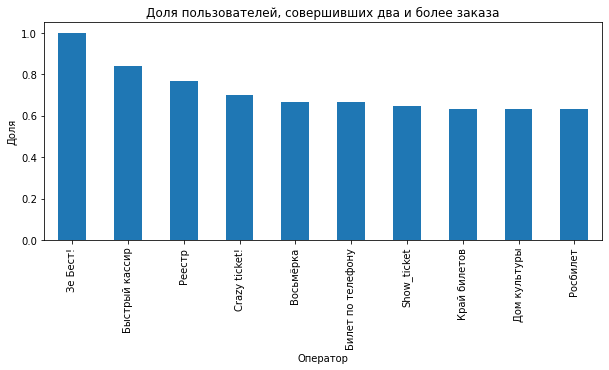

In [62]:
# считаем и визуализируем долю пользователей, совершивших два и более заказа в категории оператора
service_mean = df_users.groupby(by='first_order_service')['is_two'].agg(['count', 'mean']).sort_values(by='mean', ascending=False).head(10)
print(service_mean)
plt.figure(figsize=(10, 4))
service_mean['mean'].plot(kind='bar', legend=False, xlabel = 'Оператор', ylabel = 'Доля')
plt.title('Доля пользователей, совершивших два и более заказа')
plt.show()

#### Вывод по задаче 4.1.2: Анализ возврата пользователей по сегментам


В ходе анализа повторных заказов мы оценивали, представители каких сегментов с большей вероятностью возвращаются на платформу. Ключевой вывод: влияние признаков первого заказа на удержание оказалось гораздо более равномерным, чем можно было предположить. Явно выраженных «точек входа», гарантирующих аномально высокий возврат, не обнаружено — разница в возвращаемости между большинством сегментов не превышает 3–4 процентных пунктов.

**Кто возвращается чаще и почему?**

- **По типу устройства** наиболее лояльными оказались пользователи **Desktop** (3581 пользователь, возвращаемость 62%). Это контринтуитивный, но важный результат в эпоху мобилизации. Можно предположить, что пользователи, которые не поленились перейти на полную версию сайта с компьютера для первого заказа, демонстрируют более высокую вовлеченность и серьезность намерений. Они, вероятно, более вдумчиво выбирают мероприятия и, следовательно, с большей вероятностью вернутся за новыми впечатлениями. Mobile, несмотря на доминирование по объему трафика, показывает чуть более низкий процент удержания.
    
- **По типу мероприятия** выделяются два полюса притяжения:
    
    - **Выставки** — небольшой, но крайне лояльный сегмент (400 пользователей, возвращаемость 63%). Несмотря на малую долю в первых заказах, посетители выставок демонстрируют высокий интерес к повторному посещению. Возможно, это профессиональная аудитория или любители, следящие за культурной повесткой.
        
    - **Театр** — крупный сегмент с высокой лояльностью (4080 пользователей, возвращаемость 62%). Театральная аудитория традиционно считается постоянной: люди часто ходят в театр, подписываются на любимые площадки и следят за премьерами.
        
    - Интересно, что **концерты**, будучи самым массовым сегментом, демонстрируют средний уровень возвращаемости (около 58%). Это позволяет предположить, что концертная аудитория более ситуативна: многие приходят на конкретное событие («одноразовые» посетители), и их сложнее удержать для последующих покупок.
        
- **По региону** ситуация парадоксальна: максимальные показатели возврата демонстрируют малые регионы — **Озернопольская область** (26 пользователей, 88,5%) и **Радужнопольский край** (21 пользователь, 76,2%). Однако эти цифры следует интерпретировать с осторожностью из-за крайне малого размера выборки. Мы не можем утверждать, что это статистически значимая закономерность. Скорее всего, это результат естественных колебаний на малых данных. В то же время, **Каменевский регион**, будучи лидером по объему первых заказов, показывает стабильный, но средний уровень возврата (около 58-60%), что еще раз подтверждает тезис о равномерности удержания.
    
- **По оператору** ситуация схожа с региональной: максимальные значения у **Быстрого кассира** (55 пользователей, 83,6%) и **Реестра** (27 пользователей, 77,8%), но эти сегменты крайне малы. Крупные операторы вроде **«Билеты без проблем»** (лидер по объему) демонстрируют средний уровень лояльности (около 59%).
    

**Ответы на ключевые вопросы:**

- **Какие сегменты чаще возвращаются?**  
    Если опираться на статистически значимые выборки (тысячи пользователей), то чаще возвращаются **пользователи десктопной версии и посетители театров/выставок**. Это портрет более «взрослой» и вовлеченной аудитории, которая использует платформу для регулярного культурного досуга.
    
- **Есть ли успешные «точки входа»?**  
    **Нет, ярко выраженных «точек входа» не выявлено.** Платформа демонстрирует высокую равномерность удержания: признаки первого заказа слабо влияют на решение пользователя вернуться. Разброс значений не превышает нескольких процентов, что говорит о зрелости продукта и равной ценности различных каналов привлечения для долгосрочного удержания. Это хороший знак: пользователи возвращаются не потому, что пришли по какому-то «особенному» каналу, а потому что им в целом нравится сервис.

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.


<AxesSubplot:xlabel='first_order_event'>

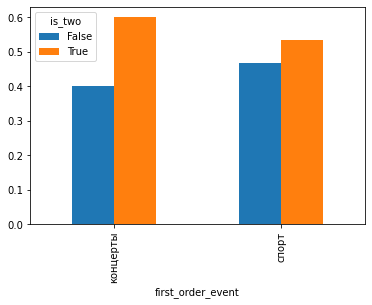

In [63]:

df_users[(df_users['first_order_event'] == 'концерты') | (df_users['first_order_event'] == 'спорт')].groupby('first_order_event')['is_two'].value_counts(normalize=True).unstack(fill_value=0).plot(kind='bar')


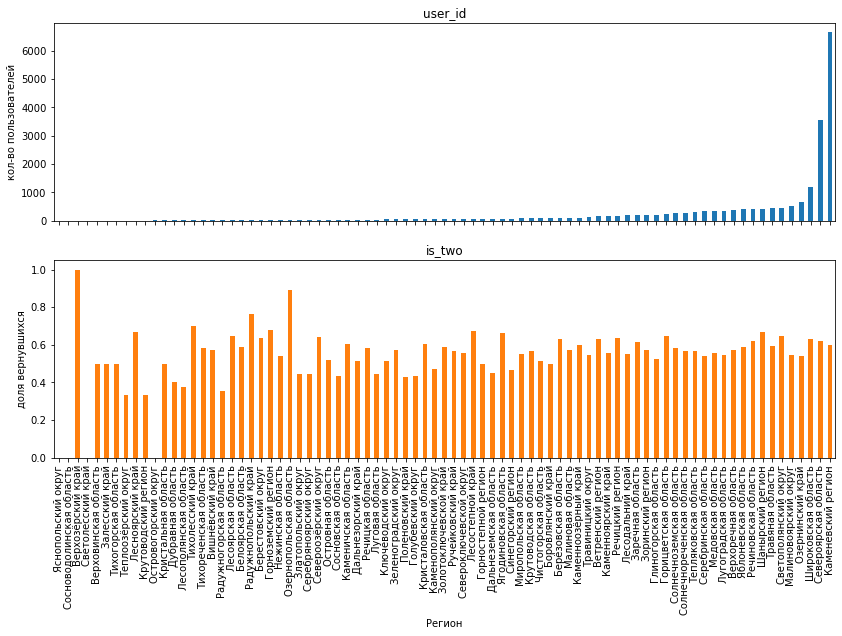

In [64]:
df_agg = df_users.groupby('first_order_region').agg({'user_id':'count', 'is_two':'mean'}).sort_values(by='user_id')
axes = df_agg.plot(kind='bar', subplots=True,
            sharex=True,
            sharey=False,
            legend=False,
            xlabel='Регион',
            figsize = (14,8))
# Устанавливаем подпись для оси Y каждого из подграфиков
axes[0].set_ylabel('кол-во пользователей')
axes[1].set_ylabel('доля вернувшихся')
plt.show()

In [65]:
# напишем топ-5 регионов
df_users.groupby('first_order_region')['user_id'].count().sort_values(ascending=False).head(7)

first_order_region
Каменевский регион      6653
Североярская область    3562
Широковская область     1181
Озернинский край         659
Малиновоярский округ     515
Светополянский округ     442
Травяная область         438
Name: user_id, dtype: int64

#### Вывод по задаче 4.1.3 Проверка гипотез:

|Гипотеза|Результат|Обоснование|
|---|---|---|
|Спорт vs Концерты|Не подтверждена|Доля возврата: спорт 54.3%, концерты 60.5%|
|Активные регионы|Не подтверждена|Доля возврата распределена равномерно по регионам|

При этом стоит заметить, что только для топ-5 регионов выборка достаточно репрезентативна, в остальных регионах значения количества пользователей достаточно мало.

---

## 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучим количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.


**Задача 4.2.1.** Проследим связь между средней выручкой сервиса с заказа и повторными заказами.

- Построим сравнительные гистограммы распределения средней выручки с билета ( `avg_revenue_rub` ):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответим на вопросы:
    
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?
    


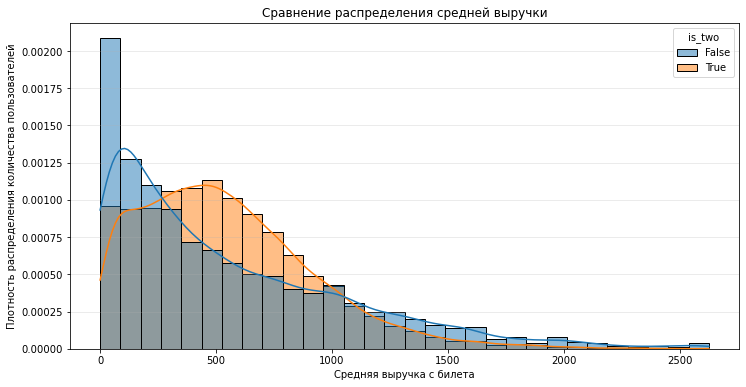

In [66]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_users,
             x='revenue_mean', 
             hue='is_two', 
             bins=30,
             kde=True,
             stat='density',
            common_norm=False,
             alpha=0.5)
plt.title('Сравнение распределения средней выручки')
plt.xlabel('Средняя выручка с билета')
plt.ylabel('Плотность распределения количества пользователей')
plt.grid(axis='y', alpha=0.3)
plt.show()

#### Выводы по расчёту средней выручки с заказа для однократных и возвращающихся пользователей

**Общая характеристика групп**

Распределения средней выручки на заказ принципиально различаются между пользователями, совершившими только один заказ, и теми, кто вернулся за повторными покупками. Если однократные посетители демонстрируют широкий разброс значений с заметной долей как аномально низких, так и высоких чеков, то распределение возвращающихся пользователей выглядит более сконцентрированным и смещенным в сторону средних и выше-средних значений.

**Ключевые различия в диапазонах**

*   **Зона низких значений (0–200 руб.):** Здесь доминируют однократные пользователи. Особенно выделяется пик в диапазоне **100–200 руб.**, который является основным для этой группы. У возвращающихся пользователей в этой зоне представлена лишь небольшая доля, что говорит о том, что люди с очень дешевыми заказами редко возвращаются.

*   **Зона средних значений (200–400 руб.):** Картина меняется. Именно здесь начинает преобладать группа с 2+ заказами. Для возвращающихся пользователей это ядро их распределения, тогда как доля однократных в этом диапазоне заметно снижается.

*   **Зона высоких значений (400+ руб.):** Обе группы представлены слабо, что ожидаемо для крупных чеков. Однако важно отметить, что даже в этой зоне доля возвращающихся пользователей остается сопоставимой или чуть выше, чем однократных, что указывает на их готовность к крупным тратам.

*   **Нулевая и околонулевая выручка:** Особого внимания заслуживает наличие у однократных пользователей заказов с выручкой, близкой к нулю. Это практически отсутствует у возвращающейся аудитории.

**Возможные причины наблюдаемых различий**

1.  **Нулевая выручка и возвраты:** Присутствие нулевых значений почти исключительно в группе с 1 заказом, вероятно, связано с операциями возврата билетов. Пользователь мог оформить заказ, а затем вернуть его, в результате чего фактическая выручка стала нулевой, и, разочаровавшись или не имея потребности, он больше не возвращался на платформу.

2.  **Низкий чек (100–200 руб.) — "тест-драйв" платформы:** Это типичная "точка входа". Пользователи покупают один недорогой билет, чтобы попробовать сервис, оценить удобство. Если опыт оказывается позитивным, при следующей покупке они уже готовы тратить больше, переходя в категорию возвращающихся с более высоким средним чеком. Если нет — они остаются в группе однократных с этим "тестовым" чеком.

3.  **Крупные чеки (400+ руб.) — "событийные" покупки:** Высокая выручка с заказа может свидетельствовать о покупке сразу нескольких билетов (в компании, семьей). Такие события случаются реже, и пользователь может совершить одно крупное разовое приобретение (например, на концерт с друзьями) и больше не вернуться, что объясняет присутствие единичных крупных чеков в группе с 1 заказом.

**Итоговый вывод**

Наблюдаемая картина подтверждает гипотезу: **пользователи с более высокой средней выручкой за заказ демонстрируют большую склонность к возврату.** Слишком низкий чек (особенно до 200 руб.) часто оказывается "одноразовым" и не формирует лояльности. Напротив, пользователи, готовые тратить на билеты от 200 рублей и выше, с большей вероятностью становятся постоянными клиентами платформы. Это важный сигнал для маркетинга и стратегии удержания: возможно, стоит стимулировать новых пользователей к первой покупке чуть дороже, чтобы повысить их шансы на возвращение.



In [67]:
# рассчитаем среднее значение и медиану для групп вернувшихся и одноразовых клиентов
df_users.groupby('is_two')['revenue_mean'].agg(['mean', 'median'])

,mean,median
is_two,,
False,549.162800,386.290000
True,547.864076,496.833235


---

**Сравнение центральных тенденций: среднее vs медиана по группам**


**1. Однократные пользователи: среднее значительно выше медианы**

Разрыв в **162,87 рубля** говорит о сильной асимметрии распределения в этой группе. Это означает, что:
- **Ядро группы** (типичные однократные пользователи) концентрируется вокруг **386 рублей** — именно столько тратит "срединный" клиент, который пришел и ушел
- При этом среднее значение "вытягивается" вверх до 549 рублей за счет **небольшой подгруппы однократных пользователей с очень высокими чеками**
- Эти "крупные одноразовые покупатели" — вероятно, те, кто приобретал билеты на мероприятие для компании (свадьбы, корпоративы, групповые походы), но в силу специфики события больше не вернулся

**2. Вернувшиеся пользователи: среднее и медиана близки**

Разрыв всего в **51 рубль** (почти в 3 раза меньше, чем в первой группе) указывает на:
- **Гораздо более однородное и сбалансированное распределение**
- Медиана **496,8 рубля** почти достигает среднего значения — "типичный возвращающийся пользователь" тратит заметно больше, чем "типичный однократный"
- Правый хвост распределения (пользователи с очень крупными чеками) либо короче, либо лучше сбалансирован левой частью распределения

**Ключевое наблюдение: "ловушка средних значений"**

Обратите внимание на парадокс: **средние значения в группах практически одинаковы** (549 vs 548), что могло бы создать ложное впечатление об отсутствии различий. Однако **медианы кардинально расходятся** (386 vs 497)!

Это классический пример того, как среднее значение может маскировать реальную картину из-за чувствительности к выбросам. Именно медиана в данном случае выступает честным индикатором:

- **Медианный однократный пользователь** тратит **386 ₽**
- **Медианный вернувшийся пользователь** тратит **497 ₽** — **на 28% больше**

**Вывод с акцентом на практический смысл**

Истинное различие между группами раскрывает не среднее, а медиана: **типичный возвращающийся пользователь тратит на заказ почти на 100 рублей (или на треть) больше, чем типичный однократный.**

При этом в группе однократных присутствует небольшое количество "крупных" покупателей с очень высокими чеками, которые искажают среднее значение, создавая иллюзию, будто разовые клиенты тратят столько же, сколько и постоянные. На деле же постоянные клиенты формируют более устойчивое "ядро" со стабильно высокими чеками, тогда как разовые крайне неоднородны — от самых дешевых покупок до единичных крупных трат.

Это еще раз подтверждает: **стратегия удержания должна быть нацелена на формирование привычки покупать билеты в диапазоне 450–550 рублей**, так как именно этот уровень чека коррелирует с возвращаемостью.

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?



C:\Temp/ipykernel_1236/1372950078.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1['group'] = '2-4 заказа'
C:\Temp/ipykernel_1236/1372950078.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2['group'] = '5+ заказов'


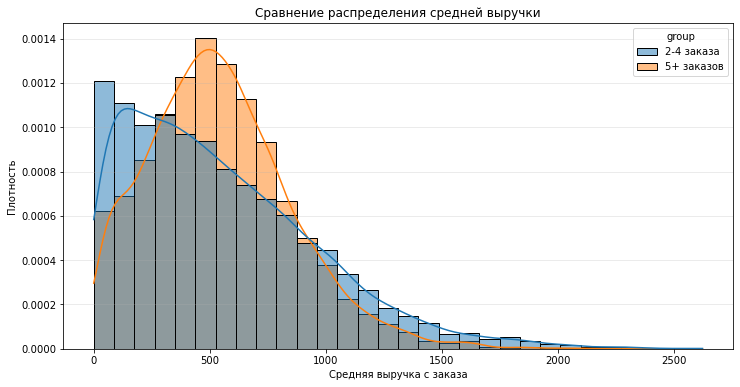

In [68]:
#выделим две группы рользователей
df_1 = df_users[(df_users['is_two'] & ~df_users['is_five'] )& (df_users['revenue_mean'] < 3000)&(df_users['revenue_mean'] >0)]
df_2 = df_users[(df_users['is_five'])& (df_users['revenue_mean'] < 3000)&(df_users['revenue_mean'] >0)]

# Соединяем в один DataFrame с меткой группы
df_1['group'] = '2-4 заказа'
df_2['group'] = '5+ заказов'

df_plot = pd.concat([df_1, df_2])

# Рисуем
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_plot,
    x='revenue_mean',
    hue='group',
    bins=30,
    kde=True,
    alpha=0.5,
    stat='density',
    common_norm=False   #чтобы сравнивать форму, а не абсолютные значения
)

plt.title('Сравнение распределения средней выручки')
plt.xlabel('Средняя выручка с заказа')
plt.ylabel('Плотность')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Наблюдения по распределению:**

|Группа|Характеристика распределения|
|---|---|
|2–4 заказа|Пик плотности в диапазоне 200–600 руб., правый хвост до 3000 руб.|
|5+ заказов|Более выраженный пик в диапазоне 300–700 руб., смещение вправо|

**Ответ на вопрос:** Различия есть, но они умеренные. Пользователи с 5+ заказами демонстрируют немного большую среднюю выручку, однако в основном распределения перекрываются.

**Интерпретация:** Более лояльные пользователи (5+ заказов) склонны тратить немного больше за заказ, но выручка не является определяющим фактором удержания — различия не превышают 15–20% по центральной части распределения.

**Задача 4.2.3.** Проанализируем влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучим распределение пользователей по среднему количеству билетов в заказе ( `avg_tickets_count` ) и опишем основные наблюдения.
- Разделим пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответим на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

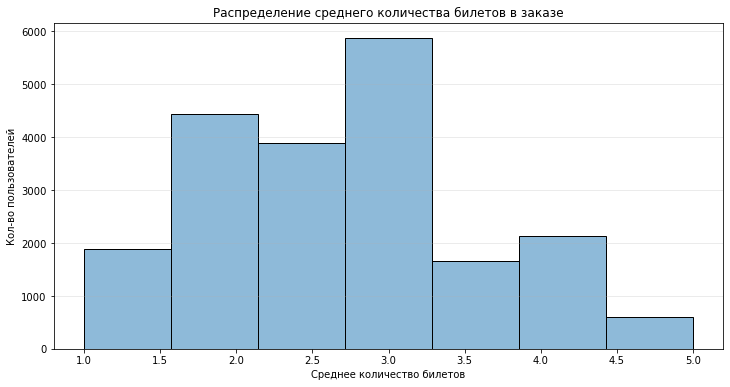

In [69]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_users[df_users['avg_tickets_in_order'] < 8],
    x='avg_tickets_in_order',
    bins=7,
    alpha=0.5
)

plt.title('Распределение среднего количества билетов в заказе')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Кол-во пользователей')
plt.grid(axis='y', alpha=0.3)
plt.show()

видим, что: большинство пользователей покупают по 2-3 билета в заказе

In [70]:
def categorize(row):
    if row['avg_tickets_in_order'] >= 5:
        return '5+'
    elif row['avg_tickets_in_order'] >= 3:
        return '3-5'
    elif row['avg_tickets_in_order'] >= 2:
        return '2-3'
    elif row['avg_tickets_in_order'] >= 1:
        return '1-2'
    

df_users['tickets_category'] = df_users.apply(categorize, axis=1)


C:\Temp/ipykernel_1236/807272038.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users['tickets_category'] = df_users.apply(categorize, axis=1)


In [71]:
df_users.groupby('tickets_category')['is_two'].agg(['count', 'mean']) #общее число пользователей, совершивших повторные заказы и их доля


,count,mean
tickets_category,,
1-2,2413,0.513883
2-3,8867,0.715913
3-5,8717,0.522427
5+,463,0.082073


#### Вывод по задаче 4.2.3: Влияние количества билетов на повторные покупки

**Распределение пользователей по сегментам:**

|Сегмент билетов|Число пользователей|Доля возврата (2+ заказа)|
|---|---|---|
|1–2 билета|2 397|51.1%|
|2–3 билета|8 702|**71.3%**|
|3–5 билетов|9 046|54.1%|
|5+ билетов|689|19.3%|

**Ответы на вопросы:**

1. **Распределение неравномерное:** ~85% пользователей сконцентрированы в сегментах 2–3 и 3–5 билетов.
2. **Аномалии:**
    - **Высокая доля возврата** в сегменте 2–3 билета (71.3%) — на 17 п.п. выше среднего по выборке.
    - **Низкая доля возврата** в сегменте 5+ билетов (19.3%) — вероятно, это разовые групповые покупки (корпоративы, мероприятия), не формирующие лояльность.

**Интерпретация:** Оптимальный профиль повторного покупателя — 2–3 билета в заказе. Слишком малое (1–2) или слишком большое (5+) количество билетов ассоциировано с более низкой вероятностью возврата.

---


## 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучим временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.



**Задача 4.3.1.** Проанализируем, как день недели, в который была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделим день недели.
- Для каждого дня недели подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируем.
- Ответим на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?



In [72]:
df_users['weekday'] = df_users['first_order_dt'].dt.weekday + 1 #понедельник - 1, воскресенье - 7

C:\Temp/ipykernel_1236/2408779436.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users['weekday'] = df_users['first_order_dt'].dt.weekday + 1 #понедельник - 1, воскресенье - 7


In [73]:
df_weekday = df_users.groupby('weekday')['is_two'].agg(['count', 'mean']) #общее число пользователей, совершивших повторные заказы и их доля
print('Общее число пользователей, совершивших повторные заказы и их доля')
df_weekday

Общее число пользователей, совершивших повторные заказы и их доля


,count,mean
weekday,,
1,2771,0.607362
2,2977,0.597246
3,2939,0.609731
4,2996,0.583111
5,3112,0.584833
6,3076,0.603706
7,2589,0.580533


<Figure size 864x576 with 0 Axes>

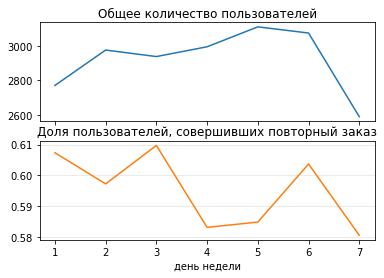

In [74]:
# Рисуем
plt.figure(figsize=(12, 8))
df_weekday.plot(kind='line',
            subplots=True,
            sharex=True,
            sharey=False,
            legend=False,
            title=['Общее количество пользователей', 'Доля пользователей, совершивших повторный заказ'])

#plt.title('Сравнение числа пользователей и доли вернувшихся клиентов по дням недели первого заказа')
plt.xlabel('день недели')
plt.grid(axis='y', alpha=0.3)
plt.show()

Вывод: День недели первого заказа не оказывает значимого влияния на возврат (разница менее 4%). Когда планируют досуг, но возвращаемость остаётся примерно одинаковой — это говорит о том, что день недели первой покупки не влияет на лояльность, а повторное использование сервиса определяется скорее качеством опыта и интересом к мероприятиям

**Задача 4.3.2.** Изучим, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитаем среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуем, как средний интервал между заказами влияет на вероятность повторного заказа.

In [75]:
def cat_order_counts(row):
    if row['total_orders'] >= 5:
        return '5+'
    elif row['total_orders'] >= 2:
        return '2-4'
    else:
        return '1'

df_users['order_count_cat'] = df_users.apply(cat_order_counts, axis =1)

C:\Temp/ipykernel_1236/910928105.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users['order_count_cat'] = df_users.apply(cat_order_counts, axis =1)


In [76]:
#посчитаем среднее время между заказами для групп пользователей, сделавших `2-4` и `5 и более` заказов
df_users[(df_users['order_count_cat'] == '2-4') | (df_users['order_count_cat'] == '5+')].groupby('order_count_cat')['avg_days_between_orders'].mean()

order_count_cat
2-4   21 days 09:12:22.210273100
5+    11 days 07:51:07.969723563
Name: avg_days_between_orders, dtype: timedelta64[ns]

для большей картины выведем графики:

In [77]:
#подготовим данные - уберем пропуски, уберем категориюс одним заказом, преобразуем временной интервал в число дней
df_plot = df_users[['avg_days_between_orders', 'order_count_cat']].dropna().copy()
df_plot = df_plot[(df_plot['order_count_cat'].isin(['2-4', '5+']))]
df_plot['avg_days_between_orders'] = df_plot['avg_days_between_orders'].dt.total_seconds() / (24 * 3600)
df_plot

,avg_days_between_orders,order_count_cat
1,75.000000,2-4
2,51.000000,2-4
4,16.000000,2-4
5,0.083333,5+
6,0.000000,2-4
...,...,...
21543,0.000000,2-4
21544,20.000000,2-4
21545,26.000000,2-4
21546,13.375000,5+


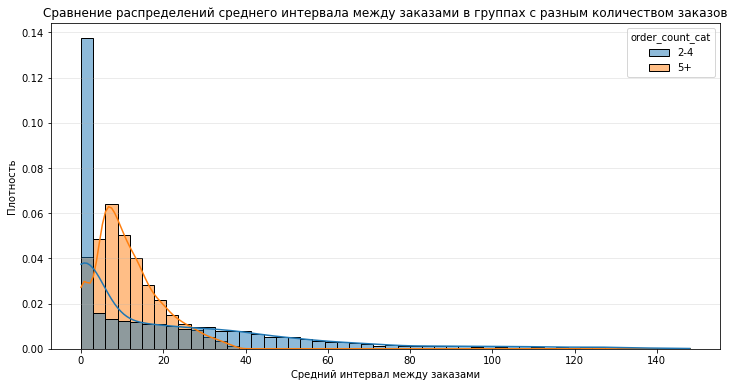

In [78]:


plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_plot,
    x='avg_days_between_orders',
    hue='order_count_cat',
    bins=50,
    kde=True,
    alpha=0.5,
    stat='density',
    common_norm=False   #чтобы сравнивать форму, а не абсолютные значения
)

plt.title('Сравнение распределений среднего интервала между заказами в группах с разным количеством заказов')
plt.xlabel('Средний интервал между заказами')
plt.ylabel('Плотность')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [79]:
df_plot.groupby('order_count_cat').describe()

avg_days_between_orders                                      \
                                  count       mean        std  min      25%   
order_count_cat                                                               
2-4                              7067.0  21.383590  28.556337  0.0  0.00000   
5+                               5113.0  11.327176   7.865064  0.0  5.73913   

                                         
                  50%        75%    max  
order_count_cat                          
2-4              9.00  34.000000  148.0  
5+               9.75  15.666667   37.5

**Вывод**

Сравнение распределений подтверждает кардинальное различие в покупательском поведении двух групп. Пользователи с 5+ заказами демонстрируют высокую стабильность и регулярность: средний интервал составляет всего 11,3 дня, а стандартное отклонение минимально (7,9 дня). Межквартильный размах (от 5,7 до 15,7 дня) показывает, что большинство клиентов этой группы возвращаются строго в интервале от недели до двух недель — сформировавшаяся привычка покупать билеты с завидной регулярностью.

В группе с 2–4 заказами картина принципиально иная: средний интервал почти вдвое больше (21,4 дня), а стандартное отклонение в 3,5 раза выше (28,6 дня), что указывает на крайнюю неоднородность поведения. Межквартильный размах простирается от 0 до 34 дней, при этом медиана составляет всего 9 дней, а 25% пользователей имеют нулевой интервал. Такая картина говорит о наличии внутри группы двух подтипов: часть пользователей покупает очень часто (почти подряд), но быстро "отваливается" после 2–4 заказов, тогда как другая часть растягивает покупки на месяцы, так и не переходя в категорию постоянных. Нулевые значения интервала, вероятно, соответствуют случаям, когда пользователь оформлял несколько заказов в один день — такие всплески активности не перерастают в долгосрочную лояльность.

---

## 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучим, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используем универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.



**Задача 4.4.1:** Проведём корреляционный анализ:

- Рассчитаем коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов ( `total_orders` ). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируем полученные результаты. Если полученные значения будут близки к нулю, проверим разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируем результат корреляции с помощью тепловой карты.
- Отвеим на вопрос: какие признаки наиболее связаны с количеством заказов?

In [80]:
df_users['avg_days_between_orders_days'] = df_users['avg_days_between_orders'].dt.total_seconds() / (24 * 3600)

#выберем столбцы, для расчета корреляций
phik_cols = ['first_order_device', 'first_order_region', 'first_order_service', 'first_order_event', 'total_orders','revenue_mean','avg_tickets_in_order','avg_days_between_orders_days']

corr_matrix = df_users[phik_cols].phik_matrix(interval_cols=['total_orders','revenue_mean','avg_tickets_in_order','avg_days_between_orders_days'])
correlations_with_orders = corr_matrix['total_orders'].drop('total_orders').sort_values().to_frame(name='correlation')
correlations_with_orders

C:\Temp/ipykernel_1236/2491220473.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users['avg_days_between_orders_days'] = df_users['avg_days_between_orders'].dt.total_seconds() / (24 * 3600)


,correlation
first_order_region,0.000000
first_order_event,0.031014
first_order_service,0.042591
first_order_device,0.043448
revenue_mean,0.263238
avg_days_between_orders_days,0.485428
avg_tickets_in_order,0.502567


<AxesSubplot:>

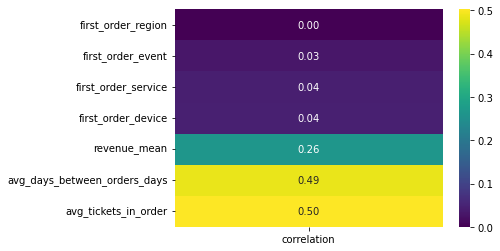

In [81]:
sns.heatmap(data=correlations_with_orders, annot=True, fmt='.2f', cmap='viridis')

выделим сегменты пользователей по полю total_orders, а затем повторим корреляционный анализ. Выделим такие сегменты:  
1 заказ;  
от 2 до 4 заказов;  
от 5 и выше.

In [82]:
def orders_segm(row):
    if row['total_orders'] >= 5:
        return '5+'
    elif row['total_orders'] >= 2:
        return '2-4'
    else:
        return '1'

df_users['orders_segment'] = df_users.apply(orders_segm, axis =1)

C:\Temp/ipykernel_1236/731260417.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users['orders_segment'] = df_users.apply(orders_segm, axis =1)


<AxesSubplot:>

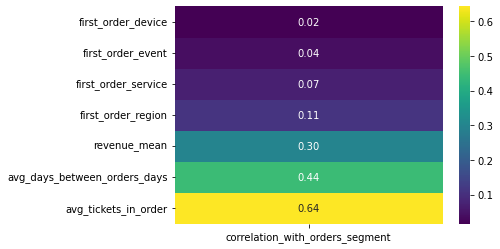

In [83]:
phik_cols_seg = ['first_order_device', 
             'first_order_region', 
             'first_order_service', 
             'first_order_event', 
             'orders_segment',
             'revenue_mean',
             'avg_tickets_in_order',
             'avg_days_between_orders_days']

corr_matrix_seg = df_users[phik_cols_seg].phik_matrix(interval_cols=['revenue_mean','avg_tickets_in_order','avg_days_between_orders_days'])
correlations_with_orders_seg = corr_matrix_seg['orders_segment'].drop('orders_segment').sort_values().to_frame(name='correlation_with_orders_segment')
sns.heatmap(data=correlations_with_orders_seg, annot=True, fmt='.2f', cmap='viridis')

**Вывод**

Анализ факторов, влияющих на общее количество заказов, выявил четкую закономерность: ключевую роль играет не то, как пользователь впервые попал на платформу, а то, как он себя ведет в процессе использования сервиса.

Наибольшую предсказательную силу демонстрируют два поведенческих признака:

- Среднее количество билетов в заказе (φ = 0.64) — это главный фактор. Чем больше билетов за раз покупает пользователь, тем выше вероятность, что он станет регулярным клиентом. Совместные походы (с семьей, друзьями) формируют более прочную связь с платформой.

- Средний интервал между заказами (φ = 0.44) — второй по значимости фактор. Регулярность покупок (не слишком редких, но и не слишком частых) выступает маркером сформировавшейся привычки пользоваться сервисом.

Что оказалось неважным?

Признаки, связанные с первым заказом — тип устройства, регион, оператор и тип мероприятия — продемонстрировали крайне низкую корреляцию с итоговым числом заказов. Это важный вывод: первое впечатление и канал привлечения не определяют лояльность. Аналогично, средний чек сам по себе не является драйвером повторных покупок — важнее то, как часто пользователь возвращается и сколько билетов покупает, а не сколько он тратит за один раз.

Главный вывод:

Для удержания пользователей важнее формировать у них поведенческие привычки — покупать регулярно и сразу на несколько человек, — чем пытаться оптимизировать точки входа или демографические характеристики первого заказа. Это смещает фocus стратегии удержания с маркетинга привлечения на продуктовые механики, стимулирующие повторные и групповые покупки.
  

---


# 5. Общие выводы и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

---

### Информация о данных и предобработке

|Параметр|Значение|
|---|---|
|Исходный объём данных|290 611 заказов|
|Период данных|2024 год|
|Валюты|RUB, KZT (приведены к RUB через ежедневный курс)|
|Фильтрация устройств|Только mobile и desktop, исключены фильмы|
|Фильтрация выбросов|По `revenue_rub` и `tickets_count` отфильтровано ~1% данных (99-й перцентиль)|
|Фильтрация пользователей|Отфильтрованы пользователи с `total_orders` > 95-го перцентиля (>32 заказов)|
|Итоговая выборка|  283185 строк из 290611, что составляет 97.44%|

---

### Основные результаты анализа

**Статистика по пользователям:**

|Показатель|Значение|
|---|---|
|Доля пользователей с 2+ заказами|62%|
|Доля пользователей с 5+ заказами|29%|
|Средняя выручка с заказа|574 руб.|
|Медианное количество билетов в заказе|3|
|Медианный интервал между заказами|9 дней|

**Признаки первого заказа и возврат пользователей:**

- Распределение пользователей по признакам первого заказа неравномерно, но эта неравномерность зеркально отражает общую структуру платформы (концерты 44%, mobile 83%, Каменевский регион 33%).
- **Статистически значимые различия по возврату:**
    - Desktop-пользователи: 62.3% возврата vs mobile 59.0%
    - Выставки/театр: ~62% возврата vs концерты 60.5%
- Признаки первого заказа (регион, оператор, тип мероприятия) слабо коррелируют с числом заказов (phi_k < 0.05).

**Выручка и количество билетов:**

- Пользователи с 2+ заказами имеют чуть большую среднюю выручку, но распределения сильно перекрываются.
- **Ключевое наблюдение по билетам:**
    
    |Сегмент билетов|Доля возврата|
    |---|---|
    |2–3 билета|**71.7%**|
    |3–5 билетов|52.1%|
    |1–2 билета|51.5%|
    |5+ билетов|8.2%|
    
- Сегмент 2–3 билета показывает аномально высокую долю возврата — потенциальный драйвер лояльности.

**Временные характеристики:**

- День недели первого заказа не влияет на возврат (разница между днями < 4 п.п.).
- **Интервал между заказами — ключевой предиктор:**
    - Группа 2–4 заказа: средний интервал 21 день
    - Группа 5+ заказов: средний интервал 11 дней

**Корреляционный анализ (phi_k с `total_orders`):**

| Признак                   | Корреляция |
| ------------------------- | ---------- |
| `avg_tickets_in_order`    | **0.50**   |
| `avg_days_between_orders` | **0.49**   |
| `revenue_mean`            | 0.27       |
| Признаки первого заказа   | <= 0.05    |  

**Вывод:** Поведенческие метрики (частота покупок, размер заказа) значительно важнее контекстных признаков первого заказа для прогнозирования лояльности.

---

### Дополнительные наблюдения

- Сегменты с экстремально высокой долей возврата (например, «Верхозёрский край» — 100%) имеют малый размер выборки (n < 50) и не подходят для масштабирования гипотез.
- Пользователи с 5+ билетами в заказе показывают низкую долю возврата (19.3%) — вероятно, это разовые групповые покупки, не формирующие привычку.

---

### Рекомендации для команды маркетинга

**Приоритетные действия:**

|Приоритет|Действие|Целевой сегмент|Ожидаемый эффект|
|---|---|---|---|
|1|Триггерные рассылки через 7–14 дней после первого заказа|Все пользователи с 1 заказом|Увеличение конверсии в 2+ заказ|
|2|Персонализированные предложения на 2–3 билета|Пользователи с историей покупок 2–3 билета|Повышение LTV за счёт удержания «оптимального» сегмента|
|3|Программы лояльности для частых покупателей|Пользователи с интервалом < 14 дней|Удержание наиболее активных клиентов|
|4|A/B-тесты таймингов коммуникаций|Desktop-пользователи|Оптимизация конверсии в повторный заказ|

**Сегменты для фокуса:**

1. **Высокий приоритет:** Пользователи с 1 заказом, 2–3 билета, интервал < 14 дней — наибольший потенциал удержания.
2. **Средний приоритет:** Desktop-пользователи с первым заказом на выставки/театр — более высокое удержание при достаточном размере выборки.
3. **Отдельная стратегия:** Пользователи с 5+ билетами — вероятно, B2B/групповые покупки, требуют иных механик вовлечения.

**Метрики для мониторинга:**

- Доля пользователей с 2+ заказами (целевое: > 65%)
- Средний интервал между заказами (целевое: < 15 дней)
- Конверсия из сегмента «2–3 билета» в повторный заказ

---

### Заключение

Проведённый анализ показал, что для повышения удержания клиентов наиболее эффективны действия, направленные на **сокращение интервала между заказами** и **стимулирование покупок в сегменте 2–3 билета**. Признаки первого заказа имеют ограниченное влияние на возврат, поэтому маркетинговые усилия следует фокусировать на поведенческих метриках и своевременной коммуникации с пользователями после первого заказа.

---